**Import library**



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

**Import dataset**

In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# membaca file csv menggunakan pandas
df = pd.read_csv("/content/gdrive/MyDrive/Machine Learning/Pertemuan5/Tugas/data/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


**Encode ke numerik**

In [ ]:
encoder = LabelEncoder()
df["Species_encoded"] = encoder.fit_transform(df["Species"])

print("\nLabel hasil encoding:")
for label, kode in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{label} = {kode}")


Label hasil encoding:
Iris-setosa = 0
Iris-versicolor = 1
Iris-virginica = 2


**Pemisah fitur (X) dan target (y)**

In [ ]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species_encoded"]

**Split data 80% training dan 20% testing**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nJumlah data training: {len(X_train)}")
print(f"Jumlah data testing : {len(X_test)}")


Jumlah data training: 120
Jumlah data testing : 30


**Buat dan latih model Decision Tree**

In [ ]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

**Prediksi - data testing**

In [ ]:
y_pred = model.predict(X_test)

**Evaluasi hasil model**

In [ ]:
print("\n=== Evaluasi Model ===")
print("Akurasi :", round(accuracy_score(y_test, y_pred), 3))
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi Model ===
Akurasi : 1.0

Laporan Klasifikasi:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


**Visualisasi pohon keputusan**

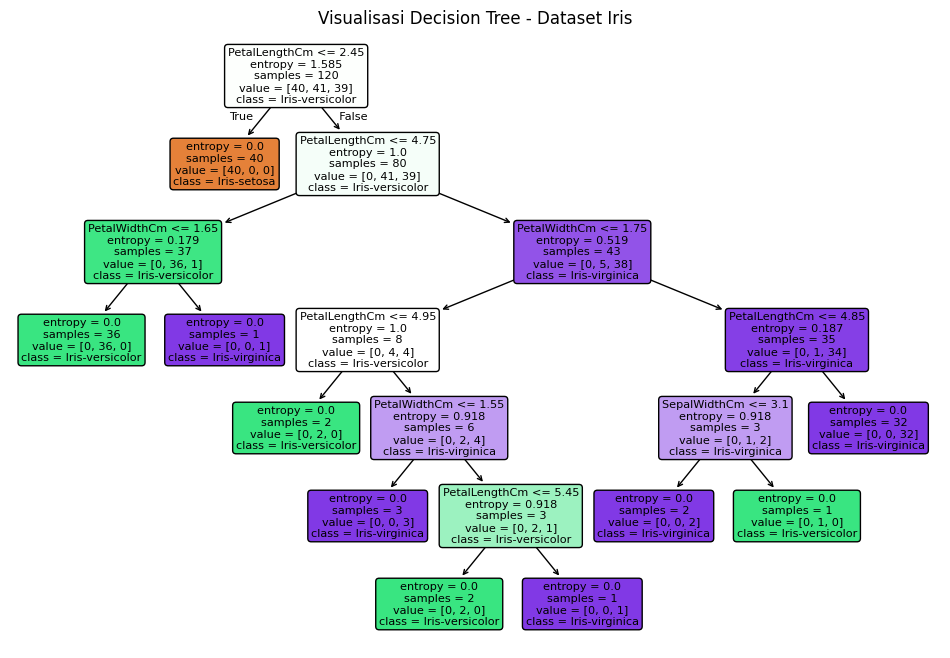

In [ ]:
plt.figure(figsize=(12,8))
tree.plot_tree(
    model,
    feature_names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
    class_names=encoder.classes_,
    filled=True,
    rounded=True
)
plt.title("Visualisasi Decision Tree - Dataset Iris")
plt.show()